# FIFA World Cup 2026 — Winner Prediction
## Notebook 04 — Monte Carlo Simulation

The goal of this notebook is to simulate the entire 2026 FIFA World Cup tournament 10,000 times using the trained XGBoost model and Monte Carlo methods to produce win probability distributions across all 48 teams.

### Objectives
- Load the trained model and 2026 fixture data
- Build group stage simulation logic
- Build knockout stage simulation logic
- Run 10,000 full tournament simulations
- Aggregate stage-reach and win probabilities per team
- Save results for visualization in notebook 05

In [1]:
import pandas as pd
import numpy as np
import joblib
import json
from pathlib import Path
from tqdm import tqdm

pd.set_option('display.max_columns', None)
np.random.seed(42)

# Paths
ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
MODELS    = ROOT / "models"

## Load Model and Data

In [2]:
# Load trained model and feature list
model = joblib.load(MODELS / "xgb_match_predictor.pkl")

with open(MODELS / "feature_list.json", "r") as f:
    feature_list = json.load(f)

# Load 2026 fixture data with features
df_matches = pd.read_csv(PROCESSED / "df_matches_2026_features.csv")
df_teams   = pd.read_csv(PROCESSED / "df_teams_2026_clean.csv")
df_stages  = pd.read_csv(PROCESSED / "df_stages_2026_clean.csv")

print(f"Model features: {feature_list}")
print(f"\nFixtures: {df_matches.shape}")
print(f"Teams: {df_teams.shape}")
print(f"Stages: {df_stages.shape}")

Model features: ['home_elo', 'home_rank', 'away_elo', 'away_rank', 'away_elo_min', 'elo_diff', 'rank_diff', 'home_win_rate', 'away_win_rate', 'home_goals_per_match', 'away_goals_per_match', 'home_conf_enc', 'away_conf_enc']

Fixtures: (104, 51)
Teams: (48, 5)
Stages: (7, 3)


## Load Real Match Results (Lock Mechanism)

Real match results are loaded from `data/processed/results.csv` and locked as fixed outcomes.
Matches without results are simulated probabilistically via XGBoost.
If the file doesn't exist, all matches are simulated (pre-tournament mode).

In [3]:
RESULTS_PATH = PROCESSED / "results.csv"

if RESULTS_PATH.exists():
    df_real_results = pd.read_csv(RESULTS_PATH)
    locked_matches = {
        int(row['match_id']): row['actual_winner']
        for _, row in df_real_results.iterrows()
        if pd.notna(row['actual_winner']) and row['actual_winner'] != ''
    }
    print(f"Loaded {len(locked_matches)} locked matches from results.csv")
else:
    locked_matches = {}
    print("No results.csv found — running in pre-tournament mode (all matches simulated)")

print(f"Locked match IDs: {list(locked_matches.keys())}")

Loaded 8 locked matches from results.csv
Locked match IDs: [2, 5, 14, 19, 20, 25, 26, 32]


## Data Preparation

In [4]:
from sklearn.preprocessing import LabelEncoder

# Rebuild the same LabelEncoder used in notebook 03
le = LabelEncoder()

# Fit on all confederation values across home and away
all_confs = pd.concat([
    df_matches['home_confederation'],
    df_matches['away_confederation']
]).dropna().unique()

le.fit(all_confs)

df_matches['home_conf_enc'] = df_matches['home_confederation'].apply(
    lambda x: le.transform([x])[0] if pd.notna(x) else -1
)
df_matches['away_conf_enc'] = df_matches['away_confederation'].apply(
    lambda x: le.transform([x])[0] if pd.notna(x) else -1
)

print("Confederation classes:", le.classes_)

Confederation classes: ['AFC' 'CAF' 'CONCACAF' 'CONMEBOL' 'OFC' 'UEFA']


In [5]:
df_groups = df_matches[df_matches['stage_id'] == 1].copy()
df_knockout = df_matches[df_matches['stage_id'] > 1].copy()

print(f"Group stage fixtures: {len(df_groups)}")
print(f"Knockout fixtures: {len(df_knockout)}")

Group stage fixtures: 72
Knockout fixtures: 32


In [6]:
team_features = {}

for _, row in df_groups.iterrows():
    for side in ['home', 'away']:
        team = row[f'{side}_team']
        if team not in team_features:
            team_features[team] = {
                'elo':             row[f'{side}_rating'],
                'rank':            row[f'{side}_rank'],
                'elo_min':         row[f'{side}_rating_min'],
                'win_rate':        row[f'{side}_win_rate'],
                'goals_per_match': row[f'{side}_goals_per_match'],
                'conf_enc':        row[f'{side}_conf_enc'],
            }

print(f"Teams in lookup: {len(team_features)}")

Teams in lookup: 48


## Match Simulation Functions

In [7]:
def predict_match(home_team, away_team, team_features, model, feature_list):
    """
    Build a feature vector for a match and return
    the model's predicted probability of home team winning.
    """
    h = team_features[home_team]
    a = team_features[away_team]

    match_vector = {
        'home_elo':             h['elo'],
        'home_rank':            h['rank'],
        'away_elo':             a['elo'],
        'away_rank':            a['rank'],
        'away_elo_min':         a['elo_min'],
        'elo_diff':             h['elo'] - a['elo'],
        'rank_diff':            h['rank'] - a['rank'],
        'home_win_rate':        h['win_rate'],
        'away_win_rate':        a['win_rate'],
        'home_goals_per_match': h['goals_per_match'],
        'away_goals_per_match': a['goals_per_match'],
        'home_conf_enc':        h['conf_enc'],
        'away_conf_enc':        a['conf_enc'],
    }

    X = pd.DataFrame([match_vector])[feature_list]
    prob_home_win = model.predict_proba(X)[0][1]
    return prob_home_win


def simulate_match(home_team, away_team, team_features, model, feature_list):
    """
    Simulate a single match outcome.
    Returns 'home' or 'away'.
    """
    prob_home_win = predict_match(home_team, away_team, team_features, model, feature_list)
    return 'home' if np.random.random() < prob_home_win else 'away'


def simulate_knockout_match(home_team, away_team, team_features, model, feature_list):
    """
    Simulate a knockout match — no draws allowed.
    Ties broken by Elo-weighted penalty probability.
    Returns the winning team name.
    """
    prob_home_win = predict_match(home_team, away_team, team_features, model, feature_list)

    # Add draw zone — if probability is close to 0.5, resolve via penalties
    draw_threshold = 0.05
    if abs(prob_home_win - 0.5) < draw_threshold:
        # Elo-weighted penalty probability
        home_elo = team_features[home_team]['elo']
        away_elo = team_features[away_team]['elo']
        penalty_prob = home_elo / (home_elo + away_elo)
        winner = home_team if np.random.random() < penalty_prob else away_team
    else:
        winner = home_team if np.random.random() < prob_home_win else away_team

    return winner

## Group Stage Simulation

In [8]:
def simulate_group_stage(df_groups, team_features, model, feature_list, locked_matches={}):
    """
    Simulate all 48 group stage matches.
    Locked matches use real results; remaining matches are simulated.
    Returns a dict of group -> sorted list of (team, points, goal_diff).
    """
    groups = {}
    simulation_log = []

    for _, match in df_groups.iterrows():
        home     = match['home_team']
        away     = match['away_team']
        group    = match['group']
        match_id = int(match['match_id'])

        # Initialize group tracking
        if group not in groups:
            groups[group] = {}
        for team in [home, away]:
            if team not in groups[group]:
                groups[group][team] = {'points': 0, 'gf': 0, 'ga': 0}

        # Lock mechanism — use real result if available
        if match_id in locked_matches:
            winner = locked_matches[match_id]
            hg = np.random.randint(1, 4)
            ag = np.random.randint(0, hg) if winner == home else np.random.randint(hg + 1, hg + 3)
            if winner == home:
                groups[group][home]['points'] += 3
            elif winner == away:
                groups[group][away]['points'] += 3
                hg, ag = ag, hg
            else:
                hg = ag = np.random.randint(0, 3)
                groups[group][home]['points'] += 1
                groups[group][away]['points'] += 1
            status = 'locked'

        else:
            prob_home_win = predict_match(home, away, team_features, model, feature_list)
            r = np.random.random()

            if r < prob_home_win * 0.85:
                hg = np.random.randint(1, 4)
                ag = np.random.randint(0, hg)
                groups[group][home]['points'] += 3
            elif r < prob_home_win * 0.85 + 0.20:
                hg = ag = np.random.randint(0, 3)
                groups[group][home]['points'] += 1
                groups[group][away]['points'] += 1
            else:
                ag = np.random.randint(1, 4)
                hg = np.random.randint(0, ag)
                groups[group][away]['points'] += 3
            status = 'predicted'

        groups[group][home]['gf'] += hg
        groups[group][home]['ga'] += ag
        groups[group][away]['gf'] += ag
        groups[group][away]['ga'] += hg

        simulation_log.append({
            'match_id': match_id,
            'home_team': home,
            'away_team': away,
            'status': status,
        })

    # Sort each group: points desc, then goal difference desc
    sorted_groups = {}
    for group, teams in groups.items():
        standings = [
            (team, stats['points'], stats['gf'] - stats['ga'])
            for team, stats in teams.items()
        ]
        standings.sort(key=lambda x: (x[1], x[2]), reverse=True)
        sorted_groups[group] = standings

    return sorted_groups, simulation_log

## Bracket Definition

The 2026 World Cup bracket is fixed and predefined. Round of 32 matchups
are determined by group positions. From Round of 16 onward, matchups follow
the winner of each Round of 32 match as defined in the official fixture.

In [9]:
def get_qualifiers(sorted_groups):
    """
    Returns two dicts:
    - group_positions: {'A': {'1': 'Argentina', '2': 'Spain', '3': 'Peru'}, ...}
    - best_thirds: list of (team, points, gd) for the 8 best third-place teams
    """
    group_positions = {}
    third_place = []

    for group, standings in sorted_groups.items():
        group_positions[group] = {
            '1': standings[0][0],
            '2': standings[1][0],
            '3': standings[2][0],
        }
        third_place.append((group, standings[2][0], standings[2][1], standings[2][2]))

    # Best 8 third-place teams by points then goal difference
    third_place.sort(key=lambda x: (x[2], x[3]), reverse=True)
    best_thirds = {t[0]: t[1] for t in third_place[:8]}  # {group: team}

    return group_positions, best_thirds

In [10]:
def resolve_r32_matchup(label, group_positions, best_thirds):
    """
    Resolve a Round of 32 match label into two team names.
    Labels follow the format '1X vs 2Y' or '1X vs 3ABCDE'.
    """
    home_label, away_label = label.split(' vs ')

    def resolve_team(token):
        position = token[0]   # '1', '2', or '3'
        groups = token[1:]    # 'A', 'BF', 'ABCDF', etc.

        if position == '3':
            # Find which of the candidate groups has a best third-place team
            for g in groups:
                if g in best_thirds:
                    return best_thirds[g]
            # Fallback — return first available third-place team
            return list(best_thirds.values())[0]
        else:
            group = groups  # single letter
            return group_positions[group][position]

    home_team = resolve_team(home_label)
    away_team = resolve_team(away_label)
    return home_team, away_team

## Knockout Stage Simulation

In [11]:
# Official Round of 32 bracket — match_id: (home_label, away_label)
R32_BRACKET = {
    73:  ('2A',       '2B'),
    74:  ('1C',       '2F'),
    75:  ('1E',       '3ABCDF'),
    76:  ('1F',       '2C'),
    77:  ('2E',       '2I'),
    78:  ('1I',       '3CDFGH'),
    79:  ('1A',       '3CEFHI'),
    80:  ('1L',       '3EHIJK'),
    81:  ('1G',       '3AEHIJ'),
    82:  ('1D',       '3BEFIJ'),
    83:  ('1H',       '2J'),
    84:  ('2K',       '2L'),
    85:  ('1B',       '3EFGIJ'),
    86:  ('2D',       '2G'),
    87:  ('1J',       '2H'),
    88:  ('1K',       '3DEIJL'),
}

# Round of 16 bracket — match_id: (r32_match_id_home, r32_match_id_away)
R16_BRACKET = {
    89:  (73, 75),
    90:  (74, 77),
    91:  (76, 78),
    92:  (79, 80),
    93:  (83, 84),
    94:  (81, 82),
    95:  (86, 88),
    96:  (85, 87),
}

# Quarter-finals bracket — match_id: (r16_match_id_home, r16_match_id_away)
QF_BRACKET = {
    97:  (89, 90),
    98:  (93, 94),
    99:  (91, 92),
    100: (95, 96),
}

# Semi-finals bracket — match_id: (qf_match_id_home, qf_match_id_away)
SF_BRACKET = {
    101: (97, 98),
    102: (99, 100),
}


def simulate_knockout_stage(group_positions, best_thirds, team_features, model, feature_list, locked_matches={}):
    """
    Simulate knockout rounds following the official 2026 World Cup bracket.
    Locked matches use real results; remaining matches are simulated.
    Returns dict with stage results, tournament winner, and simulation log.
    """
    match_winners  = {}
    simulation_log = []
    results = {
        'round_of_32':    [],
        'round_of_16':    [],
        'quarter_finals': [],
        'semi_finals':    [],
        'third_place':    None,
        'winner':         None,
    }

    def play_match(match_id, home, away):
        if match_id in locked_matches:
            winner = locked_matches[match_id]
            status = 'locked'
        else:
            winner = simulate_knockout_match(home, away, team_features, model, feature_list)
            status = 'predicted'
        simulation_log.append({
            'match_id':  match_id,
            'home_team': home,
            'away_team': away,
            'winner':    winner,
            'status':    status,
        })
        return winner

    # Round of 32
    for match_id, (home_label, away_label) in R32_BRACKET.items():
        label = f"{home_label} vs {away_label}"
        home, away = resolve_r32_matchup(label, group_positions, best_thirds)
        winner = play_match(match_id, home, away)
        match_winners[match_id] = winner
        results['round_of_32'].append(winner)

    # Round of 16
    for match_id, (home_r32, away_r32) in R16_BRACKET.items():
        home  = match_winners[home_r32]
        away  = match_winners[away_r32]
        winner = play_match(match_id, home, away)
        match_winners[match_id] = winner
        results['round_of_16'].append(winner)

    # Quarter-finals
    for match_id, (home_r16, away_r16) in QF_BRACKET.items():
        home  = match_winners[home_r16]
        away  = match_winners[away_r16]
        winner = play_match(match_id, home, away)
        match_winners[match_id] = winner
        results['quarter_finals'].append(winner)

    # Semi-finals
    sf_losers = []
    for match_id, (home_qf, away_qf) in SF_BRACKET.items():
        home  = match_winners[home_qf]
        away  = match_winners[away_qf]
        winner = play_match(match_id, home, away)
        loser  = away if winner == home else home
        match_winners[match_id] = winner
        results['semi_finals'].append(winner)
        sf_losers.append(loser)

    # Third place playoff
    if len(sf_losers) >= 2:
        third = play_match(103, sf_losers[0], sf_losers[1])
        results['third_place'] = third

    # Final
    sf_winners = [match_winners[101], match_winners[102]]
    champion = play_match(104, sf_winners[0], sf_winners[1])
    results['winner'] = champion

    return results, simulation_log

## Full Tournament Simulation

In [12]:
def simulate_tournament(df_groups, team_features, model, feature_list, locked_matches={}):
    sorted_groups, group_log = simulate_group_stage(df_groups, team_features, model, feature_list, locked_matches)
    group_positions, best_thirds = get_qualifiers(sorted_groups)
    results, knockout_log = simulate_knockout_stage(group_positions, best_thirds, team_features, model, feature_list, locked_matches)
    simulation_log = group_log + knockout_log
    return results, simulation_log

In [13]:
# Sanity check — run one simulation before the full Monte Carlo

test_result, test_log = simulate_tournament(df_groups, team_features, model, feature_list, locked_matches)

print("Winner:", test_result['winner'])
print("Third place:", test_result['third_place'])
print("Semi-finalists:", test_result['semi_finals'])
print("Quarter-finalists:", test_result['quarter_finals'])
print(f"\nSimulation log entries: {len(test_log)}")
print(f"Locked: {sum(1 for m in test_log if m['status'] == 'locked')}")
print(f"Predicted: {sum(1 for m in test_log if m['status'] == 'predicted')}")


Winner: Spain
Third place: Japan
Semi-finalists: ['England', 'Spain']
Quarter-finalists: ['Japan', 'England', 'Brazil', 'Spain']

Simulation log entries: 104
Locked: 8
Predicted: 96


## Monte Carlo — 10,000 Simulations

In [14]:
N_SIMULATIONS = 10_000

# Accumulators
wins           = {}
finals         = {}
semi_finals    = {}
quarter_finals = {}

all_teams = list(team_features.keys())
for team in all_teams:
    wins[team]           = 0
    finals[team]         = 0
    semi_finals[team]    = 0
    quarter_finals[team] = 0

for _ in tqdm(range(N_SIMULATIONS), desc="Simulating"):
    result, _ = simulate_tournament(df_groups, team_features, model, feature_list, locked_matches)

    if result['winner']:
        wins[result['winner']] = wins.get(result['winner'], 0) + 1

    for team in result['semi_finals']:
        finals[team] = finals.get(team, 0) + 1

    for team in result['quarter_finals']:
        semi_finals[team] = semi_finals.get(team, 0) + 1

    for team in result['round_of_16']:
        quarter_finals[team] = quarter_finals.get(team, 0) + 1

Simulating: 100%|██████████| 10000/10000 [35:31<00:00,  4.69it/s]


## Results

In [15]:
df_results = pd.DataFrame({
    'team': all_teams,
    'win_prob':           [wins[t] / N_SIMULATIONS for t in all_teams],
    'final_prob':         [finals[t] / N_SIMULATIONS for t in all_teams],
    'semi_final_prob':    [semi_finals[t] / N_SIMULATIONS for t in all_teams],
    'quarter_final_prob': [quarter_finals[t] / N_SIMULATIONS for t in all_teams],
})

df_results = df_results.sort_values('win_prob', ascending=False).reset_index(drop=True)

print(df_results.head(10).to_string(index=False))

       team  win_prob  final_prob  semi_final_prob  quarter_final_prob
  Argentina    0.3634      0.4499           0.5065              0.5450
      Spain    0.2742      0.4061           0.4663              0.5327
     France    0.1350      0.2458           0.5782              0.7261
    England    0.0739      0.1642           0.4315              0.6647
    Croatia    0.0342      0.1153           0.2233              0.3875
     Norway    0.0194      0.0788           0.1890              0.3545
Switzerland    0.0182      0.0943           0.2232              0.5062
     Turkey    0.0166      0.0742           0.1211              0.3656
   Portugal    0.0118      0.0588           0.1831              0.4596
   Paraguay    0.0084      0.0565           0.1150              0.3867


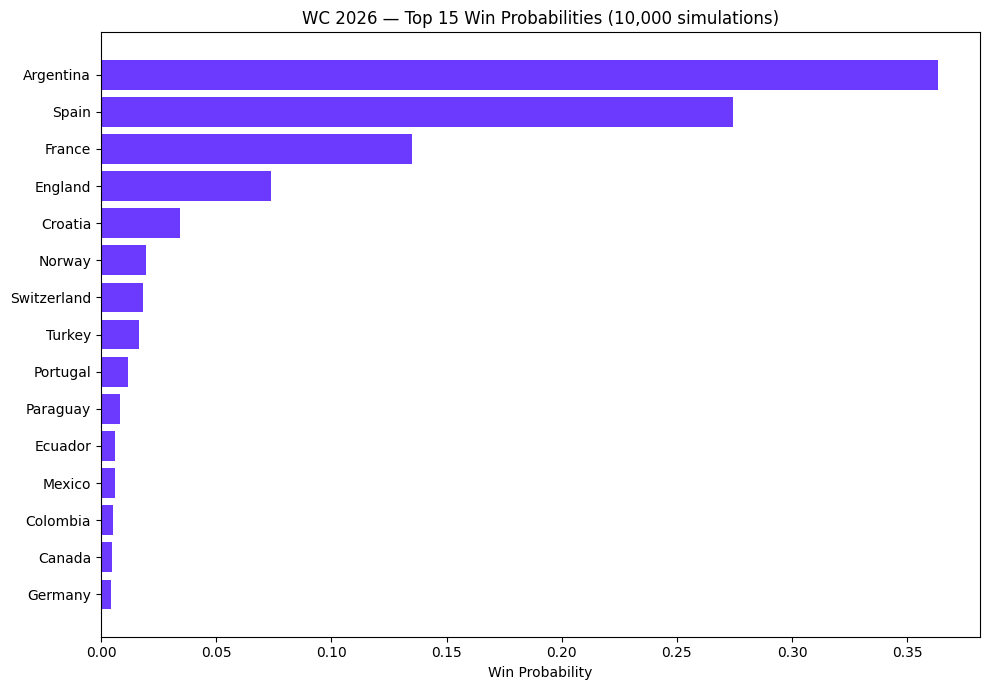

In [16]:
import matplotlib.pyplot as plt

top15 = df_results.head(15)

plt.figure(figsize=(10, 7))
plt.barh(top15['team'][::-1], top15['win_prob'][::-1], color='#6C3AFF')
plt.xlabel("Win Probability")
plt.title("WC 2026 — Top 15 Win Probabilities (10,000 simulations)")
plt.tight_layout()
plt.show()

## Save Results

In [17]:
# ── Track group positions across all simulations ─────────────────────────
from collections import defaultdict

group_position_counts = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))

for _ in tqdm(range(N_SIMULATIONS), desc="Tracking group positions"):
    sorted_groups, _ = simulate_group_stage(df_groups, team_features, model, feature_list, locked_matches)
    for group, standings in sorted_groups.items():
        for pos_idx, (team, points, gd) in enumerate(standings):
            position = pos_idx + 1
            group_position_counts[group][position][team] += 1

# Greedy assignment — ensures no team appears twice in the same group
bracket_positions = []
for group in sorted(group_position_counts.keys()):
    assigned_teams = set()
    for position in [1, 2, 3, 4]:
        # Get counts for this position, excluding already assigned teams
        counts = {
            team: count
            for team, count in group_position_counts[group][position].items()
            if team not in assigned_teams
        }
        if counts:
            most_likely = max(counts, key=counts.get)
            probability = counts[most_likely] / N_SIMULATIONS
        else:
            # Fallback — pick any unassigned team from this group
            all_group_teams = set(
                t for pos in group_position_counts[group].values()
                for t in pos
            )
            remaining = all_group_teams - assigned_teams
            most_likely = remaining.pop() if remaining else "TBD"
            probability = 0.0

        assigned_teams.add(most_likely)
        bracket_positions.append({
            'group':       group,
            'position':    position,
            'team':        most_likely,
            'probability': round(probability, 4),
        })

df_bracket_positions = pd.DataFrame(bracket_positions)
print(df_bracket_positions[df_bracket_positions['position'] <= 2].to_string(index=False))


Tracking group positions: 100%|██████████| 10000/10000 [25:16<00:00,  6.59it/s]

group  position                   team  probability
    A         1                 Mexico       0.6702
    A         2            South Korea       0.5845
    B         1                 Canada       0.8006
    B         2 Bosnia and Herzegovina       0.4219
    C         1                Morocco       0.4963
    C         2               Scotland       0.3360
    D         1               Paraguay       0.4214
    D         2                 Turkey       0.4081
    E         1                Ecuador       0.5100
    E         2                Germany       0.4072
    F         1                  Japan       0.5570
    F         2            Netherlands       0.4830
    G         1                   Iran       0.5852
    G         2                Belgium       0.3872
    H         1                  Spain       0.5143
    H         2                Uruguay       0.4484
    I         1                 France       0.5762
    I         2                 Norway       0.4044
    J       

In [18]:
# Save bracket positions for dashboard
df_bracket_positions.to_csv(PROCESSED / 'df_bracket_positions.csv', index=False)
print(f'Shape: {df_bracket_positions.shape}')

Shape: (48, 4)


In [19]:
PROCESSED.mkdir(parents=True, exist_ok=True)

# Save simulation results
df_results.to_csv(PROCESSED / "df_simulation_results.csv", index=False)

# Save simulation log from last run
_, last_log = simulate_tournament(df_groups, team_features, model, feature_list, locked_matches)
df_log = pd.DataFrame(last_log)
df_log.to_csv(PROCESSED / "df_simulation_log.csv", index=False)
print(f"\nLog summary:")
print(df_log['status'].value_counts().to_string())


Log summary:
status
predicted    96
locked        8
